# 👕 Notebook 3: Item-Based Collaborative Filtering

## ¿Cuál es la Diferencia con User-Based CF?

### **User-Based CF** (Notebook 2)
```
"Si dos USUARIOS tienen gustos similares..."
Usuario A ← similitud → Usuario B
```

### **Item-Based CF** (Este Notebook)
```
"Si dos PRODUCTOS reciben calificaciones similares..."
Producto X ← similitud → Producto Y
```

## Idea Básica

**Si un usuario le dio 5⭐ a un producto X,**
**y el producto X es SIMILAR al producto Y,**
**probablemente también le dará 5⭐ al producto Y.**

## Paso 1: Setup e Importar Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rutas
current_dir = Path().cwd()
if 'notebooks' in str(current_dir):
    BASE_DIR = current_dir.parent
else:
    BASE_DIR = current_dir

DATA_FILE = BASE_DIR / 'data' / 'raw' / 'fashion_reviews.json'
if not DATA_FILE.exists():
    possible_paths = list(BASE_DIR.glob('**/fashion_reviews.json'))
    if possible_paths:
        DATA_FILE = possible_paths[0]

print(f"✅ Setup completado")
print(f"   Base dir: {BASE_DIR}")
print(f"   Datos: {DATA_FILE.exists() and '✅' or '❌'}")

✅ Setup completado
   Base dir: d:\work\repos-deep-learning\recommendation-fashion
   Datos: ✅


In [ ]:
# Cargar datos
print("\n📥 Cargando datos...")
reviews = []
with open(DATA_FILE, 'r') as f:
    for line in f:
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews)
df = df.rename(columns={'reviewerID': 'user_id', 'asin': 'product_id', 'overall': 'rating'})

print(f"✅ {len(df):,} reviews cargados")
print(f"   Usuarios: {df['user_id'].nunique():,}")
print(f"   Productos: {df['product_id'].nunique():,}")


📥 Cargando datos...
✅ 10,000 reviews cargados
   Usuarios: 3,693
   Productos: 1,982


## Paso 2: Crear Matriz de Ratings

In [ ]:
# Matriz usuario × producto
rating_matrix = df.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='mean'
)

print(f"\n📊 MATRIZ DE RATINGS")
print(f"   Usuarios: {rating_matrix.shape[0]}")
print(f"   Productos: {rating_matrix.shape[1]}")
print(f"   Densidad: {rating_matrix.notna().sum().sum() / (rating_matrix.shape[0] * rating_matrix.shape[1]) * 100:.2f}%")


📊 MATRIZ DE RATINGS
   Usuarios: 3693
   Productos: 1982
   Densidad: 0.14%


## Paso 3: Calcular Similitud Producto-Producto

In [ ]:
# Matriz transpuesta (Productos × Usuarios)
print("\n🔢 CALCULANDO SIMILITUD PRODUCTO-PRODUCTO")
print("="*70)

# Llenar NaN con 0 para similitud
rating_matrix_T = rating_matrix.T.fillna(0)

print(f"Calculando cosine similarity para {rating_matrix_T.shape[0]} productos...\n")

# Calcular similitud
product_similarity = cosine_similarity(rating_matrix_T.values)

# DataFrame
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=rating_matrix.columns,
    columns=rating_matrix.columns
)

print(f"✅ Matriz de similitud calculada: {product_similarity_df.shape}")

# Estadísticas
similarities_no_diag = product_similarity_df.values[np.triu_indices_from(product_similarity_df.values, k=1)]
print(f"\n📈 Estadísticas:")
print(f"   Similitud media: {similarities_no_diag.mean():.4f}")
print(f"   Similitud min: {similarities_no_diag.min():.4f}")
print(f"   Similitud max: {similarities_no_diag.max():.4f}")


🔢 CALCULANDO SIMILITUD PRODUCTO-PRODUCTO
Calculando cosine similarity para 1982 productos...

✅ Matriz de similitud calculada: (1982, 1982)

📈 Estadísticas:
   Similitud media: 0.0011
   Similitud min: 0.0000
   Similitud max: 0.8729


## Paso 4: Encontrar Productos Similares

In [5]:
# Ejemplo: productos similares a uno específico
producto_ejemplo = rating_matrix.columns[10]
similitudes = product_similarity_df[producto_ejemplo].sort_values(ascending=False)

print(f"\n🔍 PRODUCTOS SIMILARES A: {producto_ejemplo}")
print("="*70)

# Info del producto
usuarios_que_lo_compraron = rating_matrix[producto_ejemplo].notna().sum()
rating_promedio = df[df['product_id'] == producto_ejemplo]['rating'].mean()

print(f"\n📊 Información del Producto:")
print(f"   Usuarios: {usuarios_que_lo_compraron}")
print(f"   Rating promedio: {rating_promedio:.2f}⭐")

print(f"\n🔗 Top 5 Productos MÁS SIMILARES:")
for i, (prod, sim) in enumerate(similitudes.iloc[1:6].items(), 1):
    rating_sim = df[df['product_id'] == prod]['rating'].mean()
    users_sim = rating_matrix[prod].notna().sum()
    print(f"   {i}. {prod}")
    print(f"      Similitud: {sim:.4f} | Rating: {rating_sim:.2f}⭐ | Usuarios: {users_sim}")


🔍 PRODUCTOS SIMILARES A: B00000010

📊 Información del Producto:
   Usuarios: 6
   Rating promedio: 4.00⭐

🔗 Top 5 Productos MÁS SIMILARES:
   1. B00001821
      Similitud: 0.1811 | Rating: 3.60⭐ | Usuarios: 5
   2. B00001881
      Similitud: 0.1570 | Rating: 2.75⭐ | Usuarios: 4
   3. B00001287
      Similitud: 0.1275 | Rating: 3.88⭐ | Usuarios: 8
   4. B00000420
      Similitud: 0.1093 | Rating: 3.00⭐ | Usuarios: 3
   5. B00000978
      Similitud: 0.0850 | Rating: 3.88⭐ | Usuarios: 8


## Paso 5: Función de Predicción Robusta

In [ ]:
def predict_rating_item_based(user_id, product_id, rating_matrix, similarity_df, k=10):
    """
    Predice rating usando similitud de productos.

    Retorna siempre un valor válido 1-5 o NaN explícito.
    """
    try:
        # Obtener ratings del usuario
        user_ratings = rating_matrix.loc[user_id]

        # Productos que el usuario revisó
        rated_items = user_ratings[user_ratings.notna()].index.tolist()

        if len(rated_items) == 0:
            # Sin historial, retornar promedio del producto
            avg = rating_matrix[product_id].mean()
            return float(avg) if not pd.isna(avg) else 3.0

        # Similitud del producto con los que el usuario revisó
        sims = similarity_df.loc[product_id, rated_items]

        # Top-K similares
        top_sims = sims.nlargest(k)

        if len(top_sims) == 0:
            avg = rating_matrix[product_id].mean()
            return float(avg) if not pd.isna(avg) else 3.0

        # Ratings del usuario en esos productos
        top_ratings = user_ratings[top_sims.index]

        # Calcular promedio ponderado
        numerator = (top_sims.values * top_ratings.values).sum()
        denominator = top_sims.values.sum()

        if denominator == 0:
            avg = rating_matrix[product_id].mean()
            return float(avg) if not pd.isna(avg) else 3.0

        prediction = float(numerator / denominator)
        prediction = np.clip(prediction, 1.0, 5.0)

        return prediction

    except Exception as e:
        return 3.0

print("✅ Función de predicción lista")

✅ Función de predicción lista


## Paso 6: Predicción de Ejemplo

In [7]:
# Usuario y producto de prueba
usuario_test = rating_matrix.index[0]
producto_test = rating_matrix.columns[5]

# Predicción
pred = predict_rating_item_based(usuario_test, producto_test, rating_matrix, product_similarity_df)

print(f"\n🔮 PREDICCIÓN ITEM-BASED")
print("="*70)
print(f"\nUsuario: {usuario_test}")
print(f"Producto: {producto_test}")
print(f"\nRating predicho: {pred:.2f}⭐")
print(f"Interpretación: {'Probablemente le guste' if pred >= 4 else 'Probablemente no le guste' if pred <= 2 else 'Neutral'}")


🔮 PREDICCIÓN ITEM-BASED

Usuario: A01000
Producto: B00000005

Rating predicho: 3.86⭐
Interpretación: Neutral


## Paso 7: Generar Recomendaciones

In [ ]:
def get_recommendations(user_id, rating_matrix, similarity_df, n_recs=5, k=10):
    """
    Genera recomendaciones sin NaN.
    """
    # Productos no revisados
    user_ratings = rating_matrix.loc[user_id]
    not_rated = user_ratings[user_ratings.isna()].index.tolist()

    predictions = {}
    for item in not_rated:
        pred = predict_rating_item_based(user_id, item, rating_matrix, similarity_df, k=k)
        predictions[item] = float(pred)

    if not predictions:
        return pd.DataFrame(columns=['product_id', 'predicted_rating'])

    # DataFrame ordenado
    recs = pd.DataFrame(
        [(k, v) for k, v in predictions.items()],
        columns=['product_id', 'predicted_rating']
    ).sort_values('predicted_rating', ascending=False).head(n_recs)

    return recs

print("✅ Función de recomendación lista")

✅ Función de recomendación lista


In [ ]:
# Generar recomendaciones para varios usuarios
print("\n🎯 RECOMENDACIONES ITEM-BASED")
print("="*70)

for usuario in rating_matrix.index[:5]:
    print(f"\n👤 Usuario: {usuario}")

    # Info usuario
    user_data = rating_matrix.loc[usuario][rating_matrix.loc[usuario].notna()]
    print(f"   Productos revisados: {len(user_data)}")
    print(f"   Rating promedio: {user_data.mean():.2f}⭐")

    # Recomendaciones
    recs = get_recommendations(usuario, rating_matrix, product_similarity_df, n_recs=5)

    if len(recs) > 0:
        print(f"\n   Top {len(recs)} Recomendaciones:")
        for idx, row in recs.iterrows():
            rating = float(row['predicted_rating'])
            stars = '⭐' * int(round(rating))
            print(f"      {row['product_id']}: {rating:.2f}/5 {stars}")
    else:
        print(f"   ⚠️  No hay recomendaciones disponibles")


🎯 RECOMENDACIONES ITEM-BASED

👤 Usuario: A01000
   Productos revisados: 2
   Rating promedio: 4.50⭐

   Top 5 Recomendaciones:
      B00000492: 5.00/5 ⭐⭐⭐⭐⭐
      B00000522: 5.00/5 ⭐⭐⭐⭐⭐
      B00000056: 5.00/5 ⭐⭐⭐⭐⭐
      B00001058: 5.00/5 ⭐⭐⭐⭐⭐
      B00000041: 5.00/5 ⭐⭐⭐⭐⭐

👤 Usuario: A01001
   Productos revisados: 1
   Rating promedio: 5.00⭐

   Top 5 Recomendaciones:
      B00000522: 5.00/5 ⭐⭐⭐⭐⭐
      B00000578: 5.00/5 ⭐⭐⭐⭐⭐
      B00000550: 5.00/5 ⭐⭐⭐⭐⭐
      B00000056: 5.00/5 ⭐⭐⭐⭐⭐
      B00001868: 5.00/5 ⭐⭐⭐⭐⭐

👤 Usuario: A01002
   Productos revisados: 1
   Rating promedio: 1.00⭐

   Top 5 Recomendaciones:
      B00000522: 5.00/5 ⭐⭐⭐⭐⭐
      B00000578: 5.00/5 ⭐⭐⭐⭐⭐
      B00000550: 5.00/5 ⭐⭐⭐⭐⭐
      B00000417: 5.00/5 ⭐⭐⭐⭐⭐
      B00000687: 5.00/5 ⭐⭐⭐⭐⭐

👤 Usuario: A01003
   Productos revisados: 3
   Rating promedio: 3.33⭐

   Top 5 Recomendaciones:
      B00001665: 5.00/5 ⭐⭐⭐⭐⭐
      B00000056: 5.00/5 ⭐⭐⭐⭐⭐
      B00000492: 5.00/5 ⭐⭐⭐⭐⭐
      B00001339: 5.00/5 ⭐⭐⭐⭐⭐
      B0

## Paso 8: Evaluación del Modelo

In [ ]:
# Preparar validación
print("\n📊 EVALUACIÓN ITEM-BASED CF")
print("="*70)

n_samples = min(100, len(df))
validation = df.sample(n=n_samples, random_state=42)

# Matriz de entrenamiento (sin validation)
df_train = df.drop(validation.index)
rm_train = df_train.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='mean'
)

# Similitud de productos (entrenamiento)
rm_train_T = rm_train.T.fillna(0)
sim_train = cosine_similarity(rm_train_T.values)
sim_train_df = pd.DataFrame(
    sim_train,
    index=rm_train.columns,
    columns=rm_train.columns
)

print(f"\nDatos de validación: {n_samples} ratings\n")

# Predicciones
y_true = []
y_pred = []

for _, row in validation.iterrows():
    user = row['user_id']
    item = row['product_id']
    true_rating = float(row['rating'])

    if user in rm_train.index and item in rm_train.columns:
        if pd.isna(rm_train.loc[user, item]):
            pred = predict_rating_item_based(user, item, rm_train, sim_train_df, k=10)
            if not pd.isna(pred):
                y_true.append(true_rating)
                y_pred.append(float(pred))

# Métricas
if len(y_true) > 0:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"✅ Predicciones: {len(y_true)}")
    print(f"\n   RMSE: {rmse:.4f}⭐")
    print(f"   MAE: {mae:.4f}⭐")
    print(f"\n   Error promedio: ±{rmse:.2f} estrellas")
else:
    print("⚠️  No hay suficientes datos para evaluar")


📊 EVALUACIÓN ITEM-BASED CF

Datos de validación: 100 ratings

✅ Predicciones: 97

   RMSE: 1.3031⭐
   MAE: 1.0677⭐

   Error promedio: ±1.30 estrellas


## Paso 9: Visualizaciones

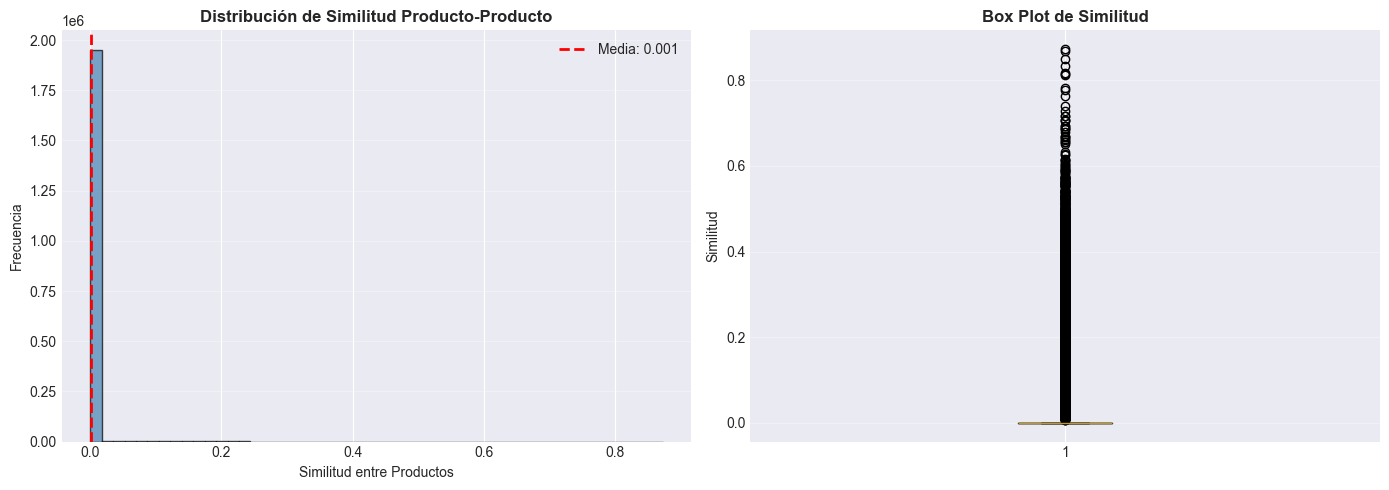

✅ Gráfico guardado


In [ ]:
# Gráfico de similitudes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1 = axes[0]
ax1.hist(similarities_no_diag, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(similarities_no_diag.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {similarities_no_diag.mean():.3f}')
ax1.set_xlabel('Similitud entre Productos')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Similitud Producto-Producto', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# Box plot
ax2 = axes[1]
ax2.boxplot(similarities_no_diag, vert=True)
ax2.set_ylabel('Similitud')
ax2.set_title('Box Plot de Similitud', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'item_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado")

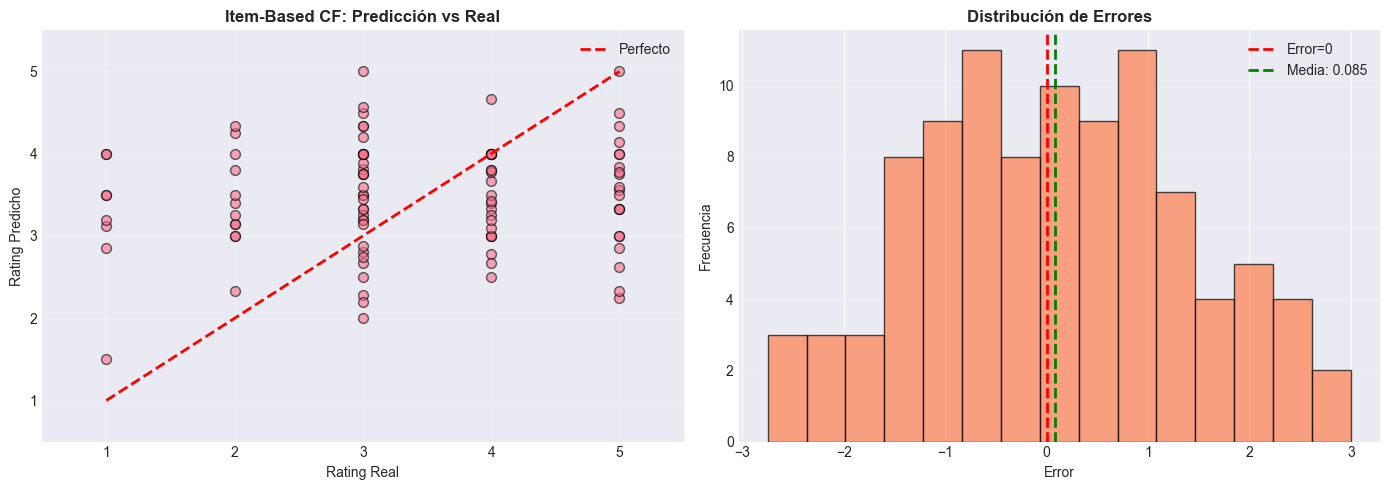

✅ Gráfico guardado


In [ ]:
# Gráfico predicción vs real (si hay datos)
if len(y_true) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter
    ax1 = axes[0]
    ax1.scatter(y_true, y_pred, alpha=0.6, s=50, edgecolor='black')
    ax1.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfecto')
    ax1.set_xlabel('Rating Real')
    ax1.set_ylabel('Rating Predicho')
    ax1.set_title('Item-Based CF: Predicción vs Real', fontweight='bold')
    ax1.set_xlim(0.5, 5.5)
    ax1.set_ylim(0.5, 5.5)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Errores
    ax2 = axes[1]
    errors = y_pred - y_true
    ax2.hist(errors, bins=15, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Error=0')
    ax2.axvline(errors.mean(), color='green', linestyle='--', linewidth=2,
                label=f'Media: {errors.mean():.3f}')
    ax2.set_xlabel('Error')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de Errores', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(BASE_DIR / 'reports' / 'item_based_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ Gráfico guardado")

## Resumen Final

In [13]:
print("\n" + "🎯 RESUMEN ITEM-BASED CF ".center(80, "="))
print()
print("✅ APRENDIZAJES:")
print(f"\n1. SIMILITUD PRODUCTO-PRODUCTO")
print(f"   - Matriz: {product_similarity_df.shape[0]} productos")
print(f"   - Similitud media: {similarities_no_diag.mean():.4f}")

print(f"\n2. PREDICCIÓN")
if len(y_true) > 0:
    print(f"   - RMSE: {rmse:.4f}⭐")
    print(f"   - MAE: {mae:.4f}⭐")
print(f"   - Usa K=10 productos más similares")

print(f"\n3. VENTAJAS")
print(f"   ✅ Rápido (menos comparaciones)")
print(f"   ✅ Bueno con usuarios nuevos")
print(f"   ✅ Recomendaciones explicables")

print(f"\n4. DESVENTAJAS")
print(f"   ❌ Malo con productos nuevos")
print(f"   ❌ Tiende a recomendar lo obvio")

print("\n" + "="*80)
print("\n📚 PRÓXIMO: Notebook 4 - Matrix Factorization (SVD)")
print("="*80)


============================🎯 RESUMEN ITEM-BASED CF ============================

✅ APRENDIZAJES:

1. SIMILITUD PRODUCTO-PRODUCTO
   - Matriz: 1982 productos
   - Similitud media: 0.0011

2. PREDICCIÓN
   - RMSE: 1.3031⭐
   - MAE: 1.0677⭐
   - Usa K=10 productos más similares

3. VENTAJAS
   ✅ Rápido (menos comparaciones)
   ✅ Bueno con usuarios nuevos
   ✅ Recomendaciones explicables

4. DESVENTAJAS
   ❌ Malo con productos nuevos
   ❌ Tiende a recomendar lo obvio


📚 PRÓXIMO: Notebook 4 - Matrix Factorization (SVD)
